## Building Agents
In previous notebooks we talked about a number of workflows that used LLMs in some kind of reasoning scaffolding. Patterns such as _Routing_, _Orchestrator-Worker_, _Evaluator-Optimizer_, you let the LLM decide how the control flows through the scaffolding. Now let's remove the scaffolding and talk about **Agents**.

With **Agents** you are simply allowing the LLM to perform actions, in the form of tool calls, and directly receive the output or feedback from those actions. So in the workflow cases we talked about there are pre-defined code paths that we had the LLM follow, but in the case of an Agent we remove those.

When do you actually need an Agent? You see Agents being used in cases where you have open ended problems that you cannot easily capture in a workflow. For example, you want an LLM to utilize different tools in a patterns that you just cannot predict. Agents are not guaranteed to execute tasks in a certain sequence. If your process warrents execution of tasks in sequence, prefer workflows - one of the patterns we discussed previously.

<div align="center">
<img src="images/07-Agent.png" width="450" heigh="250" alt="Orchestrator Workflow"/>
</div>

In this example we'll build an Agent with tools.

In [16]:
from dotenv import load_dotenv
from time import sleep
from rich.console import Console
from rich.markdown import Markdown
from typing import TypedDict, Annotated, List, Literal
import operator
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

In [17]:
load_dotenv(override=True)

console = Console()

In [18]:
# create our LLM - we'll be using Google Gemini flash
llm = init_chat_model("google_genai:gemini-2.5-flash", temperature=0.0)

In [19]:
# let's build some math tools
from langchain_core.tools import tool
import math


@tool
def multiply(a: int, b: int) -> int:
    """multiplies 2 integers a & b and returns product

    Args:
        a - first int
        b - second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """adds 2 integers a & b and returns sum

    Args:
        a - first int
        b - second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return math.nan if b == 0 else a / b


@tool
def subtract(a: int, b: int) -> float:
    """subtracts b from a and returns the difference

    Args:
        a: First int
        b: Second int
    """
    return a - b


# Augment the LLM with tools
tools = [add, multiply, divide, subtract]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [20]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

In [21]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

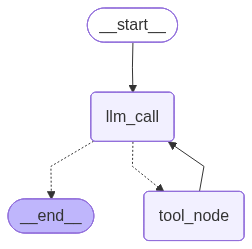

In [22]:
# Show the agent
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

This type of graph pairs the LLM with several (4 in our case) tools. Most modern LLMs, such as Gemini, OpenAI or Claude, are capable of reasoning & acting (i.e. deciding which tool to call - it looks for the doc strings to figure out which tool does what). With recursive tool calling the LLM is able to complete simple to rather complex user queries.

For example, I could ask simple questions like:

* What is the sum of 4 and 4? OR What is the product of 7 and 11?

OR I could ask more complex queries such as

* Take the sum of 7 and 11 and multiply the result by 4 and divide the result by 3

Since the LLM is connected by a loop to tool nodes, it can recursively make tool calls, each time calling the correct tools, until it determines it no longer needs to make a tool call. 

**For all the hype around agents, that's all an Agent really is! It's tool-calling in a loop.**

Let's test this out below.

**NOTE**: VS Code will pop-up an input field alon the title bar of the IDE. You may not notice it immediately. Input your query into the text field, or type exit or quit to ent the loop! In response to your queries, you should see a series of messages that will show you how the LLM reasons about which tools to call.

In [24]:
# Invoke the graph
while True:
    operation = input("Enter an arithmetic operation (e.g. 'Add 3 and 4'): ")
    if operation.strip().lower() in ["exit", "quit"]:
        break

    messages = [HumanMessage(content=operation)]
    response = agent.invoke({"messages": messages})
    for m in response["messages"]:
        m.pretty_print()

================================ Human Message =================================

subtract 7 from 13 and divide the difference by 0
================================== Ai Message ==================================
Tool Calls:
  subtract (5c747e4c-f6e1-4a8a-aa27-ec6ecf947810)
 Call ID: 5c747e4c-f6e1-4a8a-aa27-ec6ecf947810
  Args:
    a: 13.0
    b: 7.0
================================= Tool Message =================================

6
================================== Ai Message ==================================

I cannot divide by zero.


In recent versions of LangGraph (including the one we have used), the creators of LangGraph have wrapped the entire graph we created above into a simple function `create_react_agent()`. The code below shows you how to use this function.

* You'll need to instantiate an LLM of your choice (`init_chat_model(...)` call)
* You'll need to create your tool(s), as we have created above
* You'll need to bind the LLM and the tools (`llm.bind_tools([....])`)
* But you **don't have to build the graph**



In [27]:
from langgraph.prebuilt import create_react_agent

# that simple! Just provide the LLM bound to tools & the
# list of tools available to the LLM
react_agent = create_react_agent(llm_with_tools, tools)

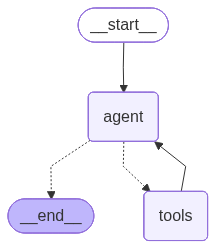

In [ ]:
# let's display it - you should see exacty the same graph as above
from IPython.display import Image, display

display(Image(react_agent.get_graph(xray=True).draw_mermaid_png()))

In [29]:
# and here is the same code to invoke the agent (duplicated from above)

while True:
    operation = input("Enter an arithmetic operation (e.g. 'Add 3 and 4'): ")
    if operation.strip().lower() in ["exit", "quit"]:
        break

    messages = [HumanMessage(content=operation)]
    # ONLY change here - instead of "agent" and am using "react_agent"
    response = agent.invoke({"messages": messages})
    for m in response["messages"]:
        m.pretty_print()

================================ Human Message =================================

subtract 7 from 13 and divide the difference by 0
================================== Ai Message ==================================
Tool Calls:
  subtract (da893937-aaf9-4d92-a927-a86f770f8179)
 Call ID: da893937-aaf9-4d92-a927-a86f770f8179
  Args:
    a: 13.0
    b: 7.0
================================= Tool Message =================================

6
================================== Ai Message ==================================

I cannot divide by zero.


#### In Conclusion

If Agents are that simple - LLMs connect to tools & called in a loop - then why don't we just do this all the time?

**A lot of problems can be solved with workflows**, which are quite a bit simpler. **Agents haven't been particular reliable till date, particularly with large number of tools or comples trajectory of tool calls**  (but that is certainly improving with some of the recent Gemini 3x, Claude 4x and OpenAI 5x models). So a lot of people still prefer workflows in Production, especially for business applications where a lot of processing must follow a certain clearly defined sequence of steps.

But if you have a very capable model, that can reason well and provide low-latency tool calling ad response, and we have confidence that they will perform more reliably in production, then we would naturally go for Agents instead of workflows. However, today most customers defer to workflows as they are a bit more trustworthy over the classic Agent pattern above.